In [1]:
import uproot ## means uproot4
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep as hep
import boost_histogram as bh
import numpy as np
import awkward as ak
from cycler import cycler

use_helvet = False ## true: use helvetica for plots, make sure the system have the font installed
if use_helvet:
    CMShelvet = hep.style.CMS
    CMShelvet['font.sans-serif'] = ['Helvetica', 'Arial']
    plt.style.use(CMShelvet)
else:
    plt.style.use(hep.style.CMS)

filedict={ 
     'ttH': '/home/pku/zhaoyz/Ntuple/OtherChannels/MERGED_Ntuple/2017/ttHToNonbb_M125_TuneCP5_13TeV-powheg-pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v2/MERGED.root',
     'HWplus':'/home/pku/zhaoyz/Ntuple/OtherChannels/MERGED_Ntuple/2017/HWplusJ_HToWW_M-125_TuneCP5_13TeV-powheg-jhugen727-pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v2/MERGED.root',
     'HWminus':'/home/pku/zhaoyz/Ntuple/OtherChannels/MERGED_Ntuple/2017/HWminusJ_HToWW_M-125_TuneCP5_13TeV-powheg-jhugen727-pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v2/MERGED.root',
     'HZ':'/home/pku/zhaoyz/Ntuple/OtherChannels/MERGED_Ntuple/2017/HZJ_HToWW_M-125_TuneCP5_13TeV-powheg-jhugen727-pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v2/MERGED.root',
     'VBF': '/home/pku/zhaoyz/Ntuple/OtherChannels/MERGED_Ntuple/2017/VBFHToWWToLNuQQ_M-125_TuneCP5_withDipoleRecoil_13TeV_powheg_jhugen751_pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v3/MERGED.root',
    
     'ttH_any': '/home/pku/zhaoyz/Ntuple/OtherChannels/MERGED_NtupleAnyNj8/2017/ttHToNonbb_M125_TuneCP5_13TeV-powheg-pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v2/MERGED.root',
     'HWplus_any':'/home/pku/zhaoyz/Ntuple/OtherChannels/MERGED_NtupleAnyNj8/2017/HWplusJ_HToWW_M-125_TuneCP5_13TeV-powheg-jhugen727-pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v2/MERGED.root',
     'HWminus_any':'/home/pku/zhaoyz/Ntuple/OtherChannels/MERGED_NtupleAnyNj8/2017/HWminusJ_HToWW_M-125_TuneCP5_13TeV-powheg-jhugen727-pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v2/MERGED.root',
     'HZ_any':'/home/pku/zhaoyz/Ntuple/OtherChannels/MERGED_NtupleAnyNj8/2017/HZJ_HToWW_M-125_TuneCP5_13TeV-powheg-jhugen727-pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v2/MERGED.root',
     'VBF_any': '/home/pku/zhaoyz/Ntuple/OtherChannels/MERGED_NtupleAnyNj8/2017/VBFHToWWToLNuQQ_M-125_TuneCP5_withDipoleRecoil_13TeV_powheg_jhugen751_pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v3/MERGED.root',
        
     'HWminus_wo':'/home/pku/zhaoyz/CustNano/OtherChannels/MERGED_2017/2017/HWminusJ_HToWW_M-125_TuneCP5_13TeV-powheg-jhugen727-pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v2/MERGED.root',
     'HWplus_wo':'/home/pku/zhaoyz/CustNano/OtherChannels/MERGED_2017/2017/HWplusJ_HToWW_M-125_TuneCP5_13TeV-powheg-jhugen727-pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v2/MERGED.root',
     'HZ_wo':'/home/pku/zhaoyz/CustNano/OtherChannels/MERGED_2017/2017/HZJ_HToWW_M-125_TuneCP5_13TeV-powheg-jhugen727-pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v2/MERGED.root',
     'VBF_wo':'/home/pku/zhaoyz/CustNano/OtherChannels/MERGED_2017/2017/VBFHToWWToLNuQQ_M-125_TuneCP5_withDipoleRecoil_13TeV_powheg_jhugen751_pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v3/MERGED.root',
     'ttH_wo':'/home/pku/zhaoyz/CustNano/OtherChannels/MERGED_2017/2017/ttHToNonbb_M125_TuneCP5_13TeV-powheg-pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v2/MERGED.root',
}


events = {key: {} for key in filedict}

for key in filedict:
    events[key] = uproot.lazy({filedict[key]: "Events"}) ## lazy means lazy computation style
    ## optional: uproot.lazy({ "$FILEPATH": "TTree", ...}) or uproot.lazy(["$FILEPATH:TTree", ...])
        

In [2]:
# events['VBF_wo'].fields

In [3]:
# for i in range(0,100):
#     print(events['ttH_any']['FatJet_pt'][i])
#     events['VBF_any']['FatJet_pt']

In [4]:
# ak.min(events['VBF_any']['FatJet_pt'],axis=1)

In [5]:
events['VBF_any']['nFatJet']

<Array [2, 2, 2, 2, 2, 2, ... 2, 2, 2, 2, 2, 2] type='498 * uint32'>

In [6]:
events['VBF_wo']['FatJet_pt']

<Array [[], [192], [], [], ... [], [], [], []] type='280000 * var * float32'>

In [7]:
np.sum(events['VBF_wo']['FatJet_pt']>200,axis=1)

<Array [0, 0, 0, 0, 0, 1, ... 0, 0, 0, 0, 0, 0] type='280000 * int64'>

In [8]:
len(events['VBF_any']['FatJet_pt'])

498

In [9]:
len(events['VBF_any']['jetAK8puppi_pt'])

498

In [10]:
events['VBF_any']['ST']

<Array [0, 0, 0, 0, 0, 0, ... 0, 0, 0, 0, 0, 0] type='498 * float32'>

In [11]:
# def CalculateNj8(sample):
#     Nj8 = [0]*len(sample['nFatJet'])
#     for i in range(0,len(sample['nFatJet'])):
#         for j in range(0,len(sample['FatJet_pt'][i])):
#             if sample['FatJet_pt'][i][j]>200:
#                 Nj8[i] += 1
                
    
#     return Nj8

In [12]:
# CalculateNj8(events['HWplus_any'])

In [13]:
# Das = ["VBF_wo","ttH_wo","HWplus_wo","HWminus_wo","HZ_wo"]

In [14]:
Nj8 = {key: {} for key in filedict}
for key in filedict:
    Nj8[key] = np.sum(events[key]['FatJet_pt']>200,axis=1)
#     ## lazy means lazy computation style
    ## optional: uproot.lazy({ "$FILEPATH": "TTree", ...}) or uproot.lazy(["$FILEPATH:TTree", ...])

In [15]:
# FileNj8above0 
events_cut = {key: {} for key in filedict}
events_cut

{'ttH': {},
 'HWplus': {},
 'HWminus': {},
 'HZ': {},
 'VBF': {},
 'ttH_any': {},
 'HWplus_any': {},
 'HWminus_any': {},
 'HZ_any': {},
 'VBF_any': {},
 'HWminus_wo': {},
 'HWplus_wo': {},
 'HZ_wo': {},
 'VBF_wo': {},
 'ttH_wo': {}}

In [16]:
# events_cut['ttH_wo'] = np.max(events['ttH_wo']['FatJet_pt']>400,axis=1)
# Nj8_cut = np.sum(events_cut['ttH_wo']['FatJet_pt']>200,axis=1)
# Nj8_cut

In [17]:
events_cut['ttH_wo'] = events['ttH_wo'][events['ttH_wo']['nFatJet'] > 0] 
events_cut['ttH_wo']

<Array [{run: 1, ... L1simulation_step: True}] type='2865113 * {"run": uint32, "...'>

In [18]:
events['ttH_wo']['nFatJet']

<Array [1, 2, 0, 2, 1, 0, ... 3, 3, 0, 3, 0, 0] type='5070989 * uint32'>

In [19]:
events_cut_2 = {key: {} for key in filedict}
events_cut_2

{'ttH': {},
 'HWplus': {},
 'HWminus': {},
 'HZ': {},
 'VBF': {},
 'ttH_any': {},
 'HWplus_any': {},
 'HWminus_any': {},
 'HZ_any': {},
 'VBF_any': {},
 'HWminus_wo': {},
 'HWplus_wo': {},
 'HZ_wo': {},
 'VBF_wo': {},
 'ttH_wo': {}}

In [20]:
# events_cut_2['ttH_wo'] = events_cut['ttH_wo'][np.max(events_cut['ttH_wo']['FatJet_pt']>400,axis=1)]

In [21]:
# maxarr = np.max(events_cut['ttH_wo']['FatJet_pt'],axis=1)>400

In [22]:
# events_cut_2['ttH_wo'] = events_cut['ttH_wo'][maxarr]

In [23]:
# np.max(events_cut['ttH_wo']['FatJet_pt'],axis=1)>400

In [24]:
# events['ttH_wo']

In [25]:
# Nj8['ttH_wo']

In [26]:
len(np.full((len(Nj8['ttH_wo'])),0.000697))

5070989

In [27]:
len(np.full((len(Nj8['VBF_wo'])),0.000697))

280000

In [28]:
len(np.full((len(Nj8['HWminus_wo'])),1))

6958752

In [29]:
len(np.full((len(Nj8['HWplus_wo'])),1))

6939262

In [30]:
0.186*1000*41.5/6939262

0.0011123661276948471

In [31]:
0.116*1000*41.5/6958752

0.0006917907118977655

In [32]:
0.35018*1000*41.5/280000

0.05190167857142858

In [33]:
0.21*1000*41.5/5070989

0.001718599665666796

In [34]:
Nj8['VBF_wo']

<Array [0, 0, 0, 0, 0, 1, ... 0, 0, 0, 0, 0, 0] type='280000 * int64'>

In [35]:
# for i in range(0,100):
# #     np.abs(events['mc']['Particle.PID'])==13
#     print(events['ttH_any']['FatJet_pt'][i])
# # events['VBF_any']['FatJet_pt']

In [36]:
# for event_muon_truth in (np.abs(events['mc']['Particle.PID'])==13):
#     print(event_muon_truth)

In [37]:
# events['mc']['Particle.PT'][events['mc']['Particle.PID']==13]

In [38]:
# np.squeeze(events['mc']['Particle.PT'][events['mc']['Particle.PID']==13])

In [39]:
# events['mc']['Nj8']

In [40]:
def plot(sample, variable, weight, bins=5, x_min=0, x_max=5, density=False, stack=False):
    ## canvas initializing
    colorlist=['red', 'blue', 'green', 'black', 'cyan', 'darkorange', 'darkviolet', 'SlateGray', 'HotPink', 'LightSkyBlue']
    mpl.rcParams['axes.prop_cycle'] = cycler(color=colorlist)
    #f, ax = plt.subplots()
    fig = plt.figure(figsize=(9,9))
    ax=plt.gca()
    plt.grid()
    hep.cms.label(data=False, year="2017", ax=ax)
    
#     for Samples in sample.keys():
#         print(Samples)
        
    
#     ## plot
#     hist = bh.Histogram(bh.axis.Regular(bins, x_min, x_max), storage=bh.storage.Weight())
    for Samples in sample.keys():
        hist = bh.Histogram(bh.axis.Regular(bins, x_min, x_max), storage=bh.storage.Weight())
#         hist.scale(weight.get(Samples))
#         values = sample.get(Samples)[variable]
        values = sample.get(Samples)
        hist.fill(values, weight=weight[Samples])
        h, err = hist.view().value, np.sqrt(hist.view().variance)
        hep.histplot(h, bins=hist.axes[0].edges, yerr=err, label=Samples, histtype='step', stack=stack)
        
#     values = sample.get("VBF")[variable]
# #     print(values)
#     hist.fill(values)
#     h, err = hist.view().value, np.sqrt(hist.view().variance)
#     hep.histplot(h, bins=hist.axes[0].edges, yerr=err, label='VBFHToWWToLNuQQ', histtype='step', density=density, stack=stack)
    # or you can specify color='blue' in the above function to cover colorlist (you could comment out colorlist too) 


    ## axises
        plt.xlim(x_min, x_max)
        plt.ylim(0, ax.get_ylim()[1]*1.1)
        ax.ticklabel_format(useOffset=False, style='plain')
    #x_major_locator=plt.MultipleLocator(bin_width*8 if variable=='fj_gen_mass' else bin_width*2)
    #y_major_locator=MultipleLocator(1)
    #ax.xaxis.set_major_locator(x_major_locator)
    #ax.yaxis.set_major_locator(y_major_locator)
        if density==False:
            plt.ylabel('Events', fontsize=20, ha='right', y=1)
        elif density==True:    
            plt.ylabel('A.U.', fontsize=20, ha='right', y=1)
        plt.xlabel('nFatJet', fontsize=20, ha='right', x=1)

        plt.xticks(size=16)
        plt.yticks(size=16)


    ## title, text and legend
    #plt.title('ROC Curve of HWW4q vs. QCD', fontsize=24,color="black")
        plt.legend(loc="best", ncol=1, frameon=False, fontsize=20)
    #plt.text(0.96*ax.get_xlim()[1], ax.get_ylim()[1]*0.72,"At "+r"$\mathrm{m^{gen}_{H}=}$"+f"{Higgsmass} GeV", fontsize=24, color="black", ha='right')


    ## finalizing
        if density==True:   suffix='_AU'
        else : suffix='Events'
        if stack==True:     suffix='_stack'
#     plt.savefig('filename'+suffix+".pdf", bbox_inches='tight')
#     plt.show()
    return fig

In [41]:
EventsList = {"HWminus":events['HWminus'],
              "HWplus":events['HWplus'],
              "HZ":events['HZ'],
              "VBF":events['VBF'],
              "ttH":events['ttH']}

EventsList_wo = {"HWminus":events['HWminus_wo'],
              "HWplus":events['HWplus_wo'],
              "HZ":events['HZ_wo'],
              "VBF":events['VBF_wo'],
              "ttH":events['ttH_wo']}

EventsList_any_Nj8 = {"HWminus":Nj8['HWminus_any'],
              "HWplus":Nj8['HWplus_any'],
              "HZ":Nj8['HZ_any'],
              "VBF":Nj8['VBF_any'],
              "ttH":Nj8['ttH_any']}


EventsList_any = {"HWminus":events['HWminus_any'],
              "HWplus":events['HWplus_any'],
              "HZ":events['HZ_any'],
              "VBF":events['VBF_any'],
              "ttH":events['ttH_any']}


EventsList2 = {
              "HWminus":events['HWminus'],
              "HWplus":events['HWplus'],
              "HZ":events['HZ'],
                "VBF":events['VBF'],

              }
EventsList8 = {
              "HWminus":events['HWminus'],
        
                "VBF":events['VBF'],

              }
EventsList3 = {
              "HWplus":events['HWminus'],
              }
EventsList4 = {
              "HWminus":events['HWminus'],
              }
EventsList5 = {
              "HZ":events['HZ'],
              }

EventsList6 = {
    "ttH":events['ttH'],
              "VBF":events['VBF'],
              }
EventsList7 = {
              "ttH":events['ttH'],
              }
EventsListVBFAny = {

              "VBF":events['VBF_any'],
              }

WeightDict = {
    "HWminus": 0.000697,
    "HWplus" : 0.001078,
    "HZ"     : 0.001306,
    "VBF"    : 0.05188,
    "ttH"    : 0.001567,
    
}


EventsList_wo_Nj8 = {"HWminus":Nj8['HWminus_wo'],
              "HWplus":Nj8['HWplus_wo'],
              "HZ":Nj8['HZ_wo'],
              "VBF":Nj8['VBF_wo'],
              "ttH":Nj8['ttH_wo']}

EventsList_Nj8 = {"HWminus":Nj8['HWminus'],
              "HWplus":Nj8['HWplus'],
              "HZ":Nj8['HZ'],
              "VBF":Nj8['VBF'],
              "ttH":Nj8['ttH']}

WeightDict_arr = {
    "HWminus": np.full((4),0.000697), 
    "HWplus" : np.full((4),0.001078),
    "HZ"     : np.full((4),0.001306),
    "VBF"    : np.full((4),0.05188),
    "ttH"    : np.full((4),0.001567),
    
}
ax = plot(sample=EventsList_Nj8,variable = "FatJet",weight = WeightDict)
plt.ylim((0,400))

(0.0, 400.0)

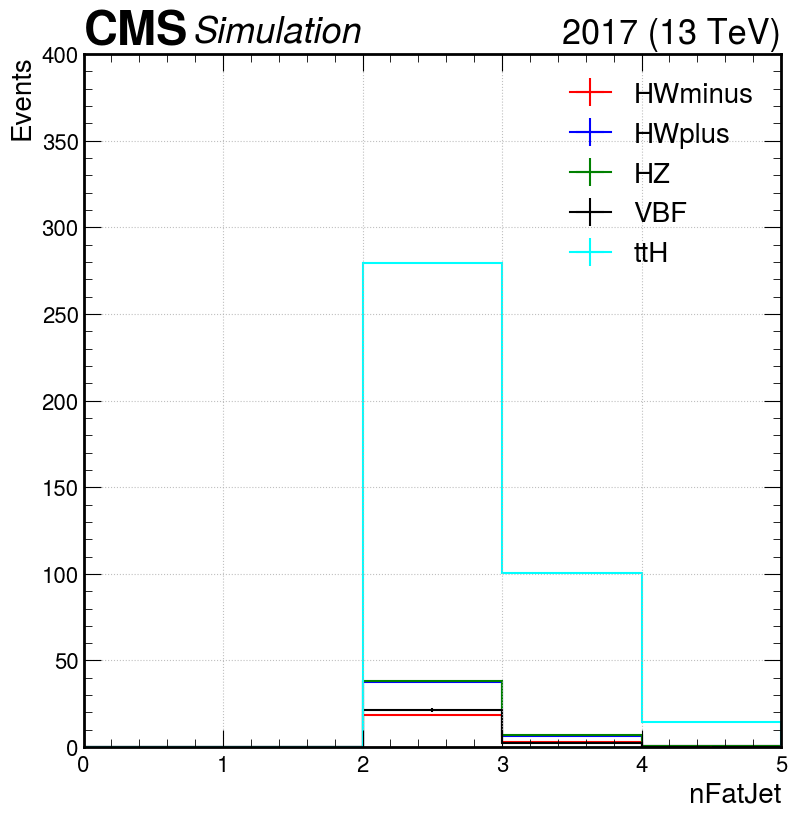

In [42]:
ax